# Завдання. Поліпшення CNN і порівняння результатів
Покращіть базову CNN із класної роботи, додайте контроль градієнтів і порівняйте результат із вихідною моделлю.

1. Додайте BatchNorm2d після кожного шару Conv2d.
2. Додайте Dropout(p=0.3) після активації ReLU.
3. Додайте gradient clipping у train loop:
    - використайте torch.nn.utils.clip_grad_norm_;
    - встановіть максимальну норму градієнтів 1.0.
4. Навчіть покращену модель на тих самих даних протягом 10 епох.
5. Збережіть значення loss для кожної епохи.
6. Побудуйте один графік, на якому порівняйте:
    - loss для базової CNN без нормалізації;
    - loss для CNN з BatchNorm, Dropout і gradient clipping.
7. Додайте до графіка назву, підписи осей і легенду.
8. Оформіть порівняння результатів у таблиці:

|Конфігурація                            |	Accuracy	|   Loss	|Примітка|
|:---|:---:|:---:|:---|
|Без нормалізації	                    |   ...	        |   ...	    |вихідна модель|
|BatchNorm + Dropout + gradient clipping|	...	        |...	    |поліпшена стабільність|

Після таблиці напишіть короткий висновок: чи стала модель стабільнішою після додавання Batch Normalization, Dropout і gradient clipping.

#### Що здати
Файл lesson_11_cnn_digits.ipynb.

In [43]:
import pandas as pd
import matplotlib.pyplot as plt

import torch 
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader
import torchvision
from torchvision import datasets, transforms 
from torchvision.utils import make_grid

In [44]:
print(torch.__version__)
print(torchvision.__version__)

2.12.1+cpu
0.27.1+cpu


In [45]:
SEED = 42
torch.manual_seed(SEED)

In [46]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
])


train_dataset = datasets.MNIST(
    root='data/',
    download=True,
    train=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root='data/',
    download=True,
    train=False,
    transform=transform
)

In [47]:
print("train dataset len: ", len(train_dataset))
print("test dataset len: ", len(test_dataset))

train dataset len:  60000
test dataset len:  10000


In [48]:
print(train_dataset)

Dataset MNIST
    Number of datapoints: 60000
    Root location: data/
    Split: Train
    StandardTransform
Transform: Compose(
               ToTensor()
               Normalize(mean=(0.1307,), std=(0.3081,))
           )


In [49]:
train_dataloader = DataLoader(
    dataset=train_dataset,
    shuffle=True,
    batch_size=64
)

test_dataloader = DataLoader(
    dataset=test_dataset,
    shuffle=False,
    batch_size=64
)

In [50]:
images, labels = next(iter(test_dataloader))
print("images shape: ", images.shape)
print("labels shape: ", labels.shape)
print("first 10 labels: ", labels[:10])

images shape:  torch.Size([64, 1, 28, 28])
labels shape:  torch.Size([64])
first 10 labels:  tensor([7, 2, 1, 0, 4, 1, 4, 9, 5, 9])


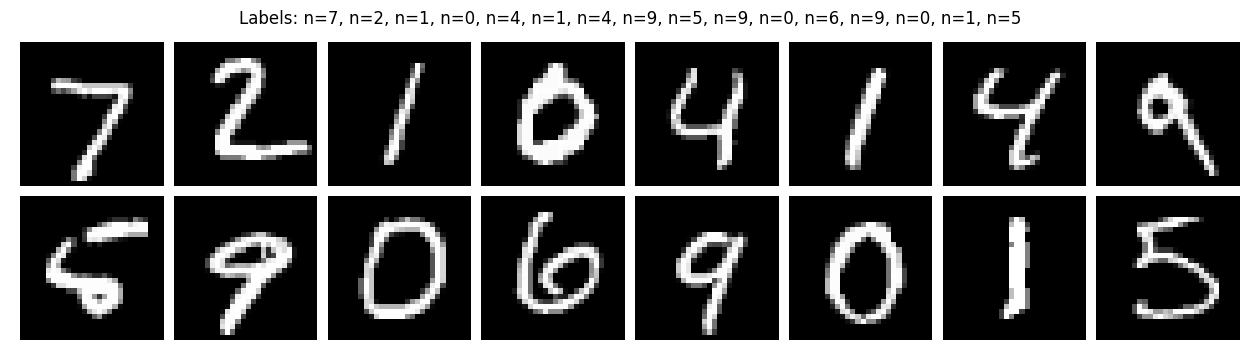

In [51]:
def show_mnist_sample(images, labels, n=16):
    grid = make_grid(images[:n], nrow=8, normalize=True, pad_value=1)
    
    plt.figure(figsize=(16, 6))
    plt.imshow(grid.permute(1, 2, 0))
    
    title = ", ".join([f"n={n}" for n in map(str, labels[:n].tolist())])
    
    plt.title("Labels: " + title)
    plt.axis("off")
    
    plt.show()
    
    
show_mnist_sample(images, labels, 16)

In [52]:
model = nn.Sequential(
    nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, padding=1),
    
    nn.ReLU(),
    nn.MaxPool2d(2),
    
    nn.Flatten(),
    nn.Linear(16 * 14 * 14, 10)
).to(device="cpu")
# функція помилок
loss_fn = nn.CrossEntropyLoss()
# оптимізатор
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [53]:
def train_one_epoch(model, dataloader, loss_fn, optimizer):
    model.train()
    
    total_loss = 0.0
    totas_items = 0
    total_correct = 0
    
    for images, labels in dataloader:
        # обнуляємо градієнти, щоб модель правильно началась
        optimizer.zero_grad(set_to_none=True)
        
        # forward pass - проходимо вперед
        logits = model(images)
    
        # рахуємо помилку
        loss = loss_fn(logits, labels)
        
        # backpropagation - рахуємо градієнти
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        
        # оновлює ваги моделі, використовує пораховані градієнти
        optimizer.step()
        
        total_loss += loss.item() * len(labels)
        totas_items += len(labels)
        total_correct += (logits.argmax(dim=1) == labels).sum().item()
        
    return {
        "loss": total_loss / totas_items,
        "accuracy": total_correct / totas_items
    }    

In [54]:
@torch.no_grad()
def evaluate(model, dataloader, loss_fn):
    model.eval()
    
    total_loss = 0.0
    total_items = 0
    total_correct = 0
    
    for images, labels in dataloader:
        # forward pass - проходимо вперед
        logits = model(images)
        
        # рахуємо помилку
        loss = loss_fn(logits, labels)
        
        total_loss += loss.item() * labels.size(0)
        total_items += labels.size(0)
        total_correct += (logits.argmax(dim=1) == labels).sum().item()
        
    return {
        "loss": total_loss / total_items,
        "accuracy": total_correct / total_items
    }

In [55]:
def model_fit(model, train_dataloader, test_dataloader, loss_fn, optimizer, epochs=10, clip_grad=None):
    history = []    
    
    for epoch in range(1, epochs + 1):
        train_metrics = train_one_epoch(model, train_dataloader, loss_fn, optimizer)
        test_metrics = evaluate(model, test_dataloader, loss_fn)
    
        row = {
            "epoch": epoch,
            "train_loss": train_metrics['loss'],
            "train_accuracy": train_metrics['accuracy'],
            "test_loss": test_metrics['loss'],
            "test_accuracy": test_metrics['accuracy']
        }
        history.append(row)
        print(row)
        
    return pd.DataFrame(history)

In [56]:
baseline_history = model_fit(model, train_dataloader, test_dataloader, loss_fn, optimizer)
baseline_history

{'epoch': 1, 'train_loss': 0.20450009489556153, 'train_accuracy': 0.94, 'test_loss': 0.09741120458096265, 'test_accuracy': 0.9704}
{'epoch': 2, 'train_loss': 0.08079450883467992, 'train_accuracy': 0.9758833333333333, 'test_loss': 0.06622517400532961, 'test_accuracy': 0.9791}
{'epoch': 3, 'train_loss': 0.06130669771383206, 'train_accuracy': 0.98185, 'test_loss': 0.0682504737276584, 'test_accuracy': 0.9784}
{'epoch': 4, 'train_loss': 0.05287359237993757, 'train_accuracy': 0.9835666666666667, 'test_loss': 0.057078555879089984, 'test_accuracy': 0.9812}
{'epoch': 5, 'train_loss': 0.04637721282641093, 'train_accuracy': 0.9858833333333333, 'test_loss': 0.05964107233975083, 'test_accuracy': 0.9813}
{'epoch': 6, 'train_loss': 0.04013869741174082, 'train_accuracy': 0.9876, 'test_loss': 0.05672473512003198, 'test_accuracy': 0.9818}
{'epoch': 7, 'train_loss': 0.03674624829698975, 'train_accuracy': 0.98875, 'test_loss': 0.06593399083944969, 'test_accuracy': 0.9788}
{'epoch': 8, 'train_loss': 0.0326

,epoch,train_loss,train_accuracy,test_loss,test_accuracy
0,1,0.204500,0.940000,0.097411,0.9704
1,2,0.080795,0.975883,0.066225,0.9791
2,3,0.061307,0.981850,0.068250,0.9784
3,4,0.052874,0.983567,0.057079,0.9812
4,5,0.046377,0.985883,0.059641,0.9813
5,6,0.040139,0.987600,0.056725,0.9818
6,7,0.036746,0.988750,0.065934,0.9788
7,8,0.032665,0.989667,0.060816,0.9816
8,9,0.028826,0.990833,0.060114,0.9822
9,10,0.025458,0.992317,0.064869,0.9811


In [ ]:
model_improved = nn.Sequential(
    nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, padding=1),
    nn.BatchNorm2d(16),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.MaxPool2d(2),

    nn.Flatten(),
    nn.Linear(16 * 14 * 14, 10)
)

optimizer_iproved = optim.Adam(model_improved.parameters(), lr=0.001)

improved_history = model_fit(
    model_improved,
    train_dataloader,
    test_dataloader,
    loss_fn,
    optimizer_iproved,
    epochs=10,
    clip_grad=1.0
)

{'epoch': 1, 'train_loss': 0.1809010329251488, 'train_accuracy': 0.9449666666666666, 'test_loss': 0.08837440350279212, 'test_accuracy': 0.9737}
{'epoch': 2, 'train_loss': 0.08856429817552368, 'train_accuracy': 0.9733333333333334, 'test_loss': 0.07069712414592505, 'test_accuracy': 0.9797}
{'epoch': 3, 'train_loss': 0.06992920773103833, 'train_accuracy': 0.9786333333333334, 'test_loss': 0.0852704893566668, 'test_accuracy': 0.971}


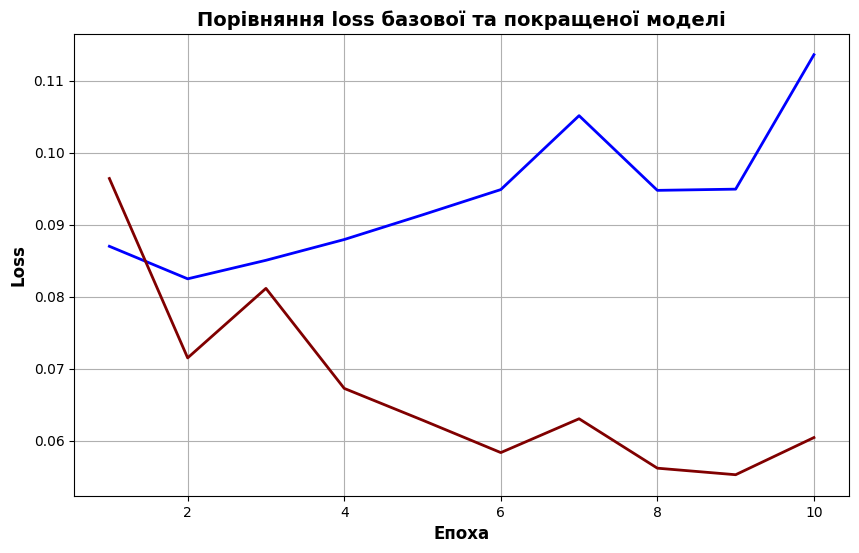

In [ ]:
from turtle import color


plt.figure(figsize=(10, 6))

plt.plot(baseline_history["epoch"], baseline_history["test_loss"], label="Базова CNN - без нормалізації", color="blue", linewidth=2) 
plt.plot(improved_history["epoch"], improved_history["test_loss"], label="CNN + BatchNorm + Dropout + Gradient Clipping", color="maroon", linewidth=2)

plt.xlabel("Епоха", fontsize=12, fontweight='bold')
plt.ylabel("Loss", fontsize=12, fontweight='bold')
plt.title("Порівняння loss базової та покращеної моделі", fontsize=14, fontweight='bold')
plt.grid(True)
plt.show()


In [ ]:
baseline_final = baseline_history.iloc[-1]
improved_final = improved_history.iloc[-1]

acc_diff = improved_final["test_accuracy"] - baseline_final["test_accuracy"]
loss_diff = improved_final["test_loss"] - baseline_final["test_loss"]

comparison = pd.DataFrame({
    "Тип моделі": [
        "Без нормалізації",
        "BatchNorm + Dropout + Gradient Clipping"
    ],
    "Accuracy": [
        baseline_final["test_accuracy"],
        improved_final["test_accuracy"]
    ],
    "Loss": [
        baseline_final["test_loss"],
        improved_final["test_loss"]
    ],
    "Різниця": [
        f"+{acc_diff*100}%",
        f"{loss_diff}"
    ],
    "Примітка": [
        f"вхідна модель",
        f"поліпшена стабільність"
    ]
     
    
})

print(comparison.to_string(index=False))


                             Тип моделі  Accuracy     Loss               Різниця               Примітка
                       Без нормалізації    0.9784 0.113595 +0.36999999999999256%          вхідна модель
BatchNorm + Dropout + Gradient Clipping    0.9821 0.060452  -0.05314244593954645 поліпшена стабільність


| Метрика | Без нормалізації | BatchNorm + Dropout + Gradient Clipping | Різниця |
|:---|:---:|:---:|:---|
| Accuracy | 97.84% | 98.21% | +0.37% |
| Loss | 0.113595 | 0.060452 | -0.053143 |

Модель з BatchNorm + Dropout + Gradient Clipping  працює значно краще. Точність зрослв +0,37%, похибка зменшилась майже в два рази - різниця в  -0.05314244593954645, ознак перенавчання немає - різниця між train і test  незначна.  Модель стала стабільнішою. 